# 05 — Grad-CAM Visualization

This notebook uses the new `src/gradcam.py` utility to inspect where a CNN is focusing.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

import matplotlib.pyplot as plt
import torch
from data_loader import DataConfig, get_cifar10_loaders
from model_cnn import SimpleCNN
from gradcam import GradCAM, tensor_to_rgb_image, overlay_heatmap
from utils import get_device


## Load data and model

For best results, use a trained checkpoint. This demo still runs with an untrained model so the workflow is visible.


In [3]:
device = get_device()
_, test_loader, classes = get_cifar10_loaders(DataConfig(batch_size=1))
images, labels = next(iter(test_loader))
image = images.to(device)

model = SimpleCNN(num_classes=len(classes)).to(device)
target_layer = model.features[6]  # last convolution layer
cam = GradCAM(model, target_layer)
result = cam(image)


100%|██████████| 170M/170M [02:16<00:00, 1.25MB/s] 


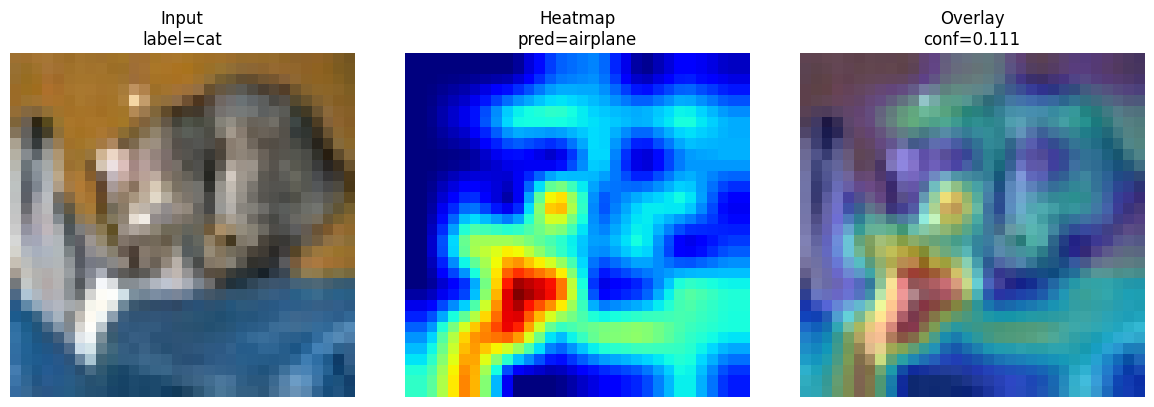

In [5]:
rgb = tensor_to_rgb_image(images)
overlaid = overlay_heatmap(rgb, result.heatmap)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(rgb)
axes[0].set_title(f"Input\nlabel={classes[labels.item()]}")

axes[1].imshow(result.heatmap, cmap="jet")
axes[1].set_title(f"Heatmap\npred={classes[result.class_idx]}")

axes[2].imshow(overlaid)
axes[2].set_title(f"Overlay\nconf={result.confidence:.3f}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

from pathlib import Path
save_dir = Path("../results/plots/gradcam")
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(save_dir / "correct_ship.png")
plt.show()

In [7]:
plt.savefig(save_dir / "correct_bird.png")

<Figure size 640x480 with 0 Axes>

In [6]:
plt.savefig(save_dir / "wrong_cat_dog.png")

<Figure size 640x480 with 0 Axes>

## Discussion

Grad-CAM highlights informative regions for one class score, but it does **not** prove causal reasoning.

Ask students:
- Does the highlighted area align with the object?
- What changes when the model is trained well versus poorly?
- How can saliency methods mislead us?
